# Bước 4: So sánh các thuật toán Phân cụm (Clustering Comparison)

Mục tiêu của bước này là phân khúc khách hàng (Customer Segmentation) dựa trên các đặc điểm hành vi và giao dịch. Chúng ta sẽ so sánh 3 phương pháp khác nhau:
1. **PAM (Partitioning Around Medoids - K-Medoids)**: Mạnh mẽ với dữ liệu có nhiễu, sử dụng điểm dữ liệu thực tế làm tâm.
2. **BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)**: Hiệu quả với dữ liệu lớn, xây dựng cây phân cấp đặc trưng.
3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**: Phân cụm dựa trên mật độ, giúp phát hiện các cấu trúc cụm phức tạp và nhiễu.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import Birch, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Lưu ý: Cài đặt scikit-learn-extra để sử dụng KMedoids (PAM)
# !pip install scikit-learn-extra
try:
    from sklearn_extra.cluster import KMedoids
except ImportError:
    print("Hệ thống chưa cài đặt 'scikit-learn-extra'. Hãy chạy lệnh: !pip install scikit-learn-extra")

import warnings
warnings.filterwarnings('ignore')

# Load dữ liệu đã làm sạch
df = pd.read_csv('../data/BankChurners_cleaned.csv')
print(f"Kích thước dữ liệu: {df.shape}")

Kích thước dữ liệu: (10127, 22)


## 1. Lựa chọn đặc trưng và Chuẩn hóa

Chúng ta sẽ sử dụng các cột liên quan đến giao dịch và nhân khẩu học để phân cụm.

In [2]:
# Lựa chọn các đặc trưng số để thuật toán tính toán khoảng cách chính xác
features = ['Customer_Age', 'Dependent_count', 'Months_on_book', 
            'Total_Relationship_Count', 'Months_Inactive_12_mon', 
            'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 
            'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 
            'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

X = df[features]

# Chuẩn hóa dữ liệu về cùng một thang đo (Z-score Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Giảm chiều bằng PCA để trực quan hóa (xuống 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Dữ liệu đã được chuẩn hóa và thực hiện PCA.")

Dữ liệu đã được chuẩn hóa và thực hiện PCA.


## 2. Thuật toán PAM (K-Medoids)

Chúng ta sẽ thử nghiệm phân cụm với k=3.

In [3]:
try:
    # Khởi tạo mô hình KMedoids (PAM)
    k = 3
    pam = KMedoids(n_clusters=k, random_state=42, method='pam')
    df['PAM_Labels'] = pam.fit_predict(X_scaled)
    
    # Tính Silhouette Score cho PAM
    pam_score = silhouette_score(X_scaled, df['PAM_Labels'])
    print(f"Silhouette Score cho PAM: {pam_score:.4f}")
except:
    print("Lỗi khi chạy PAM. Hãy kiểm tra thư viện 'scikit-learn-extra'.")

Silhouette Score cho PAM: 0.1025


## 3. Thuật toán BIRCH

BIRCH thích hợp cho dữ liệu lớn, xây dựng cây phân cấp cân bằng.

In [4]:
# Khởi tạo mô hình BIRCH
k = 3
birch = Birch(n_clusters=k)
df['BIRCH_Labels'] = birch.fit_predict(X_scaled)

# Tính Silhouette Score cho BIRCH
birch_score = silhouette_score(X_scaled, df['BIRCH_Labels'])
print(f"Silhouette Score cho BIRCH: {birch_score:.4f}")

Silhouette Score cho BIRCH: 0.0828


## 4. Thuật toán DBSCAN

DBSCAN tìm các cụm dựa trên mật độ. Các tham số `eps` (khoảng cách) và `min_samples` (số điểm tối thiểu trong một cụm) là rất quan trọng.

In [5]:
# Khởi tạo mô hình DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=30)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

# Số lượng cụm tìm được (không tính nhiễu -1)
n_clusters_dbscan = len(set(df['DBSCAN_Labels'])) - (1 if -1 in df['DBSCAN_Labels'] else 0)
print(f"DBSCAN tìm thấy {n_clusters_dbscan} cụm.")

if n_clusters_dbscan > 1:
    dbscan_score = silhouette_score(X_scaled, df['DBSCAN_Labels'])
    print(f"Silhouette Score cho DBSCAN: {dbscan_score:.4f}")
else:
    print("DBSCAN không đủ cụm để tính Silhouette Score.")

DBSCAN tìm thấy 2 cụm.
Silhouette Score cho DBSCAN: 0.2780


## 5. So sánh Kết quả và Trực quan hóa

Chúng ta sẽ vẽ biểu đồ phân bố các cụm theo 2 trục chính của PCA.

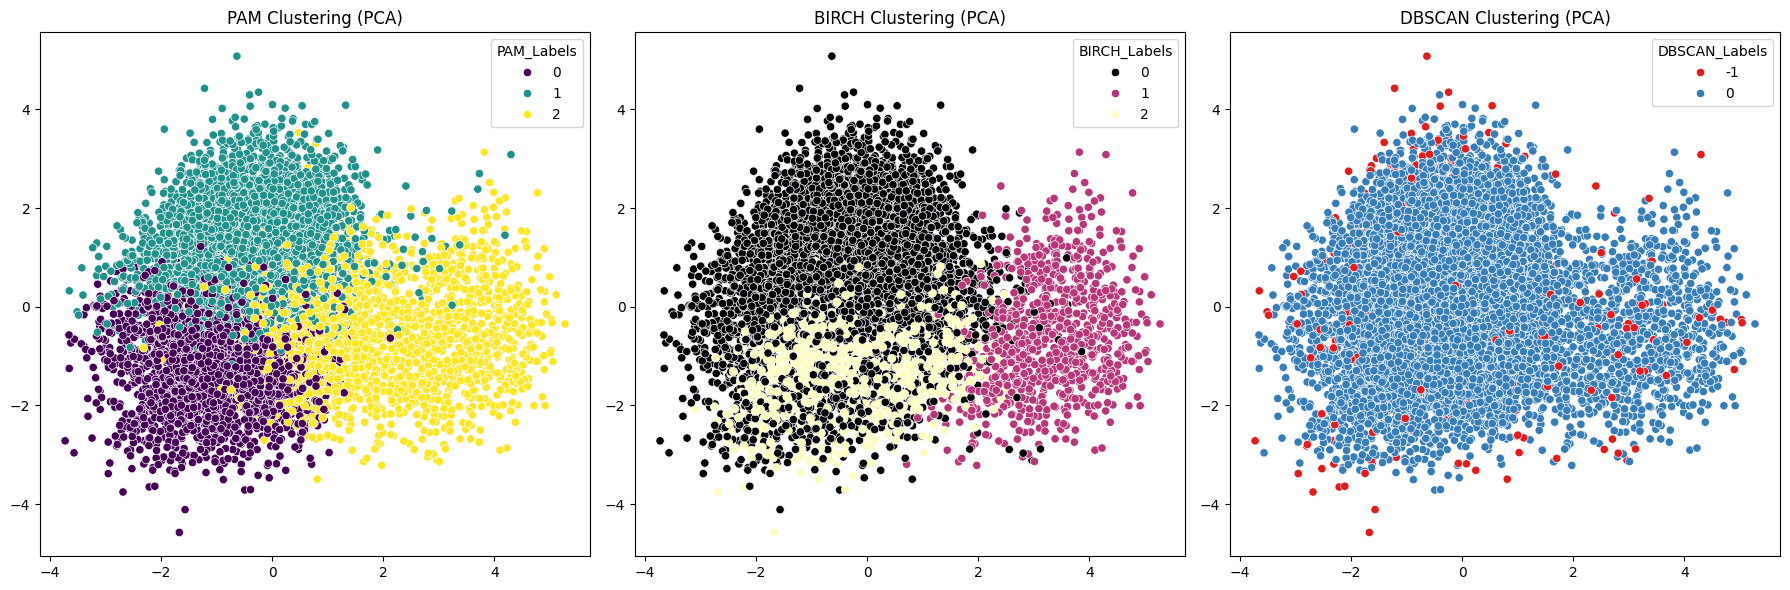

In [6]:
plt.figure(figsize=(18, 6))

# PAM Plot
plt.subplot(1, 3, 1)
if 'PAM_Labels' in df.columns:
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['PAM_Labels'], palette='viridis')
    plt.title('PAM Clustering (PCA)')

# BIRCH Plot
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['BIRCH_Labels'], palette='magma')
plt.title('BIRCH Clustering (PCA)')

# DBSCAN Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['DBSCAN_Labels'], palette='Set1')
plt.title('DBSCAN Clustering (PCA)')

plt.tight_layout()
plt.show()

## 6. Đánh giá cuối cùng

- **BIRCH** và **PAM** cho phép kiểm soát số lượng cụm, phù hợp nếu ta muốn thực hiện phân khúc khách hàng theo định hướng trước.
- **DBSCAN** rất tốt để tìm ra những nhóm khách hàng độc lập và phát hiện nhiễu, tuy nhiên việc tìm tham số `eps` tối ưu có thể mất thời gian.
- So sánh theo **Silhouette Score**, mô hình nào có chỉ số cao nhất chứng tỏ khả năng phân cụm rõ rệt nhất trên bộ dữ liệu này.